In [2]:
!pip install matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 59.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 60.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 69.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 66.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]8 [matplotlib]


In [3]:
import matplotlib.pyplot as plt
import numpy as np

In [4]:
plt.style.use("dark_background")
plt.rcParams["figure.figsize"] = (10, 8)

In [5]:
def get_linear_curve(x, w: float, b: float = 0, noise_scale: float = 0):
    return w * x + b + noise_scale * np.random.randn(x.shape[0])

In [6]:
x = np.arange(-10, 30.1, 0.5)
y = get_linear_curve(x, 1.8, 32, noise_scale=10)

In [7]:
x.shape, y.shape

((81,), (81,))

Text(0, 0.5, '°C')

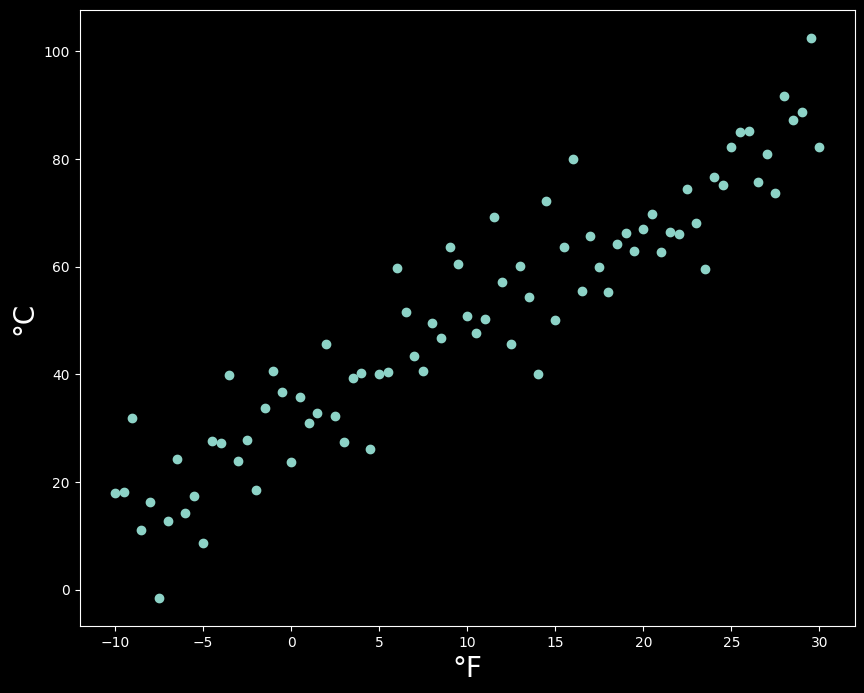

In [8]:
plt.scatter(x, y)
plt.xlabel('°F', fontsize=20)
plt.ylabel('°C', fontsize=20)

(array([7.000000e+00, 2.800000e+01, 1.310000e+02, 5.480000e+02,
        1.946000e+03, 6.940000e+03, 2.113500e+04, 5.543100e+04,
        1.297870e+05, 2.666660e+05, 4.824790e+05, 7.656000e+05,
        1.069317e+06, 1.316110e+06, 1.422622e+06, 1.357446e+06,
        1.140867e+06, 8.405880e+05, 5.449010e+05, 3.121250e+05,
        1.560820e+05, 6.912400e+04, 2.702400e+04, 9.299000e+03,
        2.820000e+03, 7.730000e+02, 1.650000e+02, 2.900000e+01,
        6.000000e+00, 4.000000e+00]),
 array([-5.25720621, -4.89768089, -4.53815557, -4.17863025, -3.81910493,
        -3.45957961, -3.10005429, -2.74052897, -2.38100365, -2.02147833,
        -1.66195302, -1.3024277 , -0.94290238, -0.58337706, -0.22385174,
         0.13567358,  0.4951989 ,  0.85472422,  1.21424954,  1.57377486,
         1.93330018,  2.2928255 ,  2.65235082,  3.01187614,  3.37140145,
         3.73092677,  4.09045209,  4.44997741,  4.80950273,  5.16902805,
         5.52855337]),
 <BarContainer object of 30 artists>)

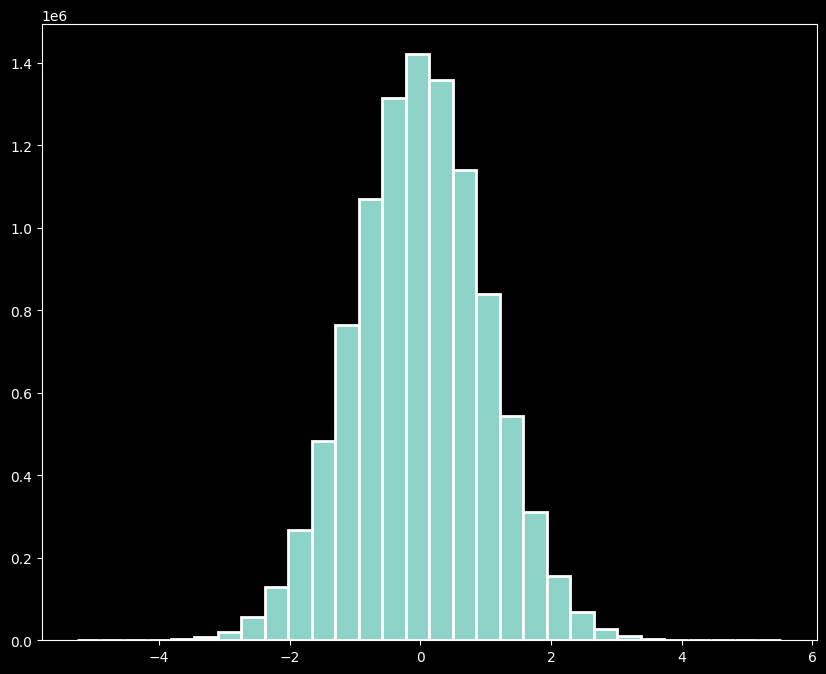

In [9]:
plt.hist(np.random.randn(10000000), bins=30, edgecolor="white", linewidth=2)

# Modelo
- Inicializar os pesos em bias
- Feedforward
- Calular a perda
- Backpropagation


In [10]:
# inicializar

peso = np.random.rand(1)
b = 0

In [11]:
def forward(inputs, w, b):
    return w * inputs + b

In [12]:
def mse(valor_real: np.ndarray, previsao: np.ndarray):
    return (valor_real - previsao) ** 2

In [13]:
def backpropagation(inputs: np.ndarray, outputs: np.ndarray, targets: np.ndarray, learning_rate: float, w, b):
    novo_peso = learning_rate * (-2 * inputs * (targets - outputs)).mean()
    novo_b = learning_rate * (-2 * (targets - outputs)).mean()

    w -= novo_peso
    b -= novo_b
    return w, b

In [14]:
def model_fit(inputs, target, w, b, epochs=200, learning_rate=0.001):
    for epoch in range(epochs):
        output = forward(inputs, w, b)
        loss = np.mean(mse(output, target))
        w, b = backpropagation(inputs, output, target, learning_rate, w, b)

        if (epoch + 1) % 50 == 0:
            print(f'epoch: [{(epoch + 1)} / {epochs}] loss: {loss:.4f}')
    return w, b

In [15]:
# inicialização
x = np.arange(-10, 10, 2)
y = get_linear_curve(x, w=1.8, b=32, noise_scale=2.5)

w = np.random.randn(1)
b = np.zeros(1)

# Treinando modelo
w, b = model_fit(x, y, w, b, epochs=1000, learning_rate=0.029)
print(f'w: {w[0]:.3f}, b: {b[0]:.3f}')

epoch: [50 / 1000] loss: 11.1975
epoch: [100 / 1000] loss: 4.0402
epoch: [150 / 1000] loss: 3.7827
epoch: [200 / 1000] loss: 3.7654
epoch: [250 / 1000] loss: 3.7642
epoch: [300 / 1000] loss: 3.7641
epoch: [350 / 1000] loss: 3.7641
epoch: [400 / 1000] loss: 3.7641
epoch: [450 / 1000] loss: 3.7641
epoch: [500 / 1000] loss: 3.7641
epoch: [550 / 1000] loss: 3.7641
epoch: [600 / 1000] loss: 3.7641
epoch: [650 / 1000] loss: 3.7641
epoch: [700 / 1000] loss: 3.7641
epoch: [750 / 1000] loss: 3.7641
epoch: [800 / 1000] loss: 3.7641
epoch: [850 / 1000] loss: 3.7641
epoch: [900 / 1000] loss: 3.7641
epoch: [950 / 1000] loss: 3.7641
epoch: [1000 / 1000] loss: 3.7641
w: 1.957, b: 33.032


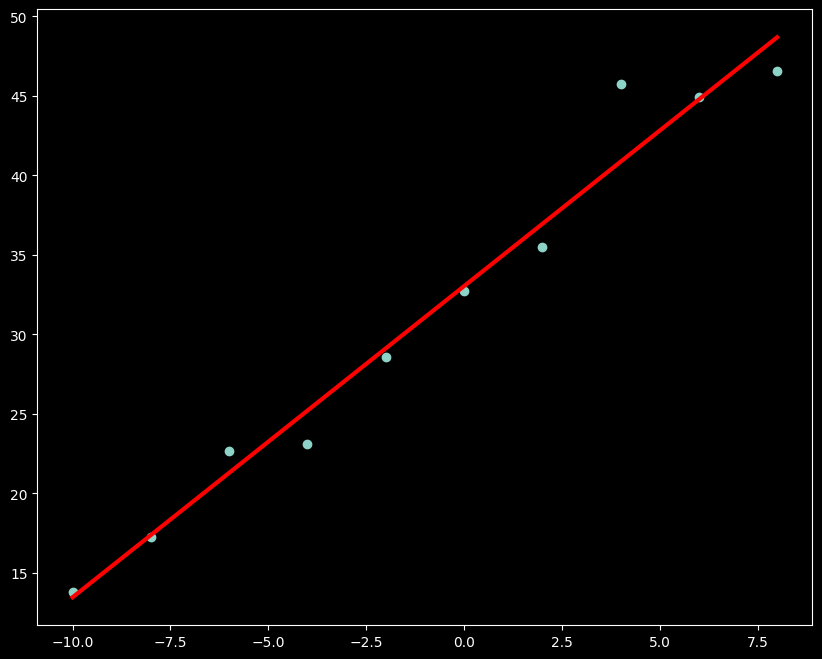

In [16]:
plt.scatter(x, y)
plt.plot(x, get_linear_curve(x, w, b), 'r', lw=3)